In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)

print("Bibliothèques importées avec succès")

Bibliothèques importées avec succès


In [3]:
df_raw = pd.read_csv("data/transformed.csv")
print(f" Données brutes : {df_raw.shape[0]} lignes, {df_raw.shape[1]} colonnes")
df_raw.head(3)

 Données brutes : 4741 lignes, 13 colonnes


,product_id,name,brand,category,site,price,url,scraped_at,category_avg_price,price_deviation,price_rank,price_zscore,is_outlier
0,iris#iris_laptop_apple_macbook_air_m4_13_pouce...,Apple MacBook Air M4 13 pouces (MC6T4),APPLE,laptop,iris,15199,https://www.iris.ma/26838-apple-macbook-air-m4...,2026-05-04 00:18:39.000000 UTC,13301.178929,1897.821071,255,0.613002,False
1,iris#iris_laptop_apple_macbook_air_m4_13_pouce...,Apple MacBook Air M4 13 pouces (MC6T4),APPLE,laptop,iris,15199,https://www.iris.ma/26838-apple-macbook-air-m4...,2026-05-04 00:18:42.000000 UTC,13301.178929,1897.821071,255,0.613002,False
2,iris#iris_laptop_epson_co_w01_vid_oprojecteur_...,EPSON CO-W01 Vidéoprojecteur WXGA (V11HA86040),EPSON,laptop,iris,4269,https://www.iris.ma/14599-epson-co-w01-videopr...,2026-05-04 00:18:39.000000 UTC,13301.178929,-9032.178929,80,-0.566347,False


In [4]:
df = df_raw.drop_duplicates(subset=['name', 'price', 'site'])

df['brand'] = df['brand'].str.upper().str.strip()

print(f"Avant nettoyage : {len(df_raw)} lignes")
print(f"Après suppression doublons : {len(df)} lignes")
print(f"Doublons supprimés : {len(df_raw) - len(df)}")
print(f"\n Catégories : {df['category'].unique()}")
print(f"Sites : {df['site'].unique()}")

Avant nettoyage : 4741 lignes
Après suppression doublons : 1763 lignes
Doublons supprimés : 2978

 Catégories : ['laptop' 'imprimante' 'logiciel' 'accessoire_tech' 'pc_fixe' 'tablet'
 'moniteur' 'smartphone' 'smartwatch']
Sites : ['iris' 'cosmostech' 'ultrapc' 'uno' 'electroplanet']


In [5]:
print("=== INFORMATIONS GÉNÉRALES ===\n")
print(df.info())
print("\n=== VALEURS MANQUANTES ===")
print(df.isnull().sum())
print("\n=== STATISTIQUES PRIX ===")
print(df['price'].describe().round(2))

=== INFORMATIONS GÉNÉRALES ===

<class 'pandas.core.frame.DataFrame'>
Index: 1763 entries, 0 to 4151
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   product_id          1763 non-null   object 
 1   name                1763 non-null   object 
 2   brand               1763 non-null   object 
 3   category            1763 non-null   object 
 4   site                1763 non-null   object 
 5   price               1763 non-null   int64  
 6   url                 1763 non-null   object 
 7   scraped_at          1763 non-null   object 
 8   category_avg_price  1763 non-null   float64
 9   price_deviation     1763 non-null   float64
 10  price_rank          1763 non-null   int64  
 11  price_zscore        1763 non-null   float64
 12  is_outlier          1763 non-null   bool   
dtypes: bool(1), float64(3), int64(2), object(7)
memory usage: 180.8+ KB
None

=== VALEURS MANQUANTES ===
product_id            0
n

In [6]:
stats_cat = df.groupby('category')['price'].agg(
    Nombre='count',
    Moyenne='mean',
    Médiane='median',
    Écart_type='std',
    Min='min',
    Max='max'
).round(2)

print("=== PRIX PAR CATÉGORIE (MAD) ===")
stats_cat

=== PRIX PAR CATÉGORIE (MAD) ===


,Nombre,Moyenne,Médiane,Écart_type,Min,Max
category,,,,,,
accessoire_tech,3,2441.33,2439.0,1552.50,890,3995
imprimante,4,3437.00,3644.5,1485.99,1769,4690
laptop,961,12847.84,10590.0,9822.01,180,74399
logiciel,2,547.00,547.0,601.04,122,972
moniteur,706,3215.37,1999.0,3820.92,119,48290
pc_fixe,3,13829.33,15899.0,4017.49,9199,16390
smartphone,56,9460.98,5874.0,8517.58,249,34999
smartwatch,11,5336.27,4749.0,3123.62,2499,11889
tablet,17,9353.65,8799.0,7377.62,480,25699


In [7]:
stats_site = df.groupby('site')['price'].agg(
    Nombre='count',
    Moyenne='mean',
    Médiane='median',
    Écart_type='std',
    Min='min',
    Max='max'
).round(2)

print("=== PRIX PAR SITE (MAD) ===")
stats_site

=== PRIX PAR SITE (MAD) ===


,Nombre,Moyenne,Médiane,Écart_type,Min,Max
site,,,,,,
cosmostech,17,2516.65,1404.0,2900.75,561,12182
electroplanet,110,9960.18,7149.0,7796.60,249,34999
iris,470,12707.12,10899.0,10994.69,122,74399
ultrapc,1157,7124.35,4290.0,7746.98,119,64499
uno,9,8265.22,390.0,16602.28,299,48290


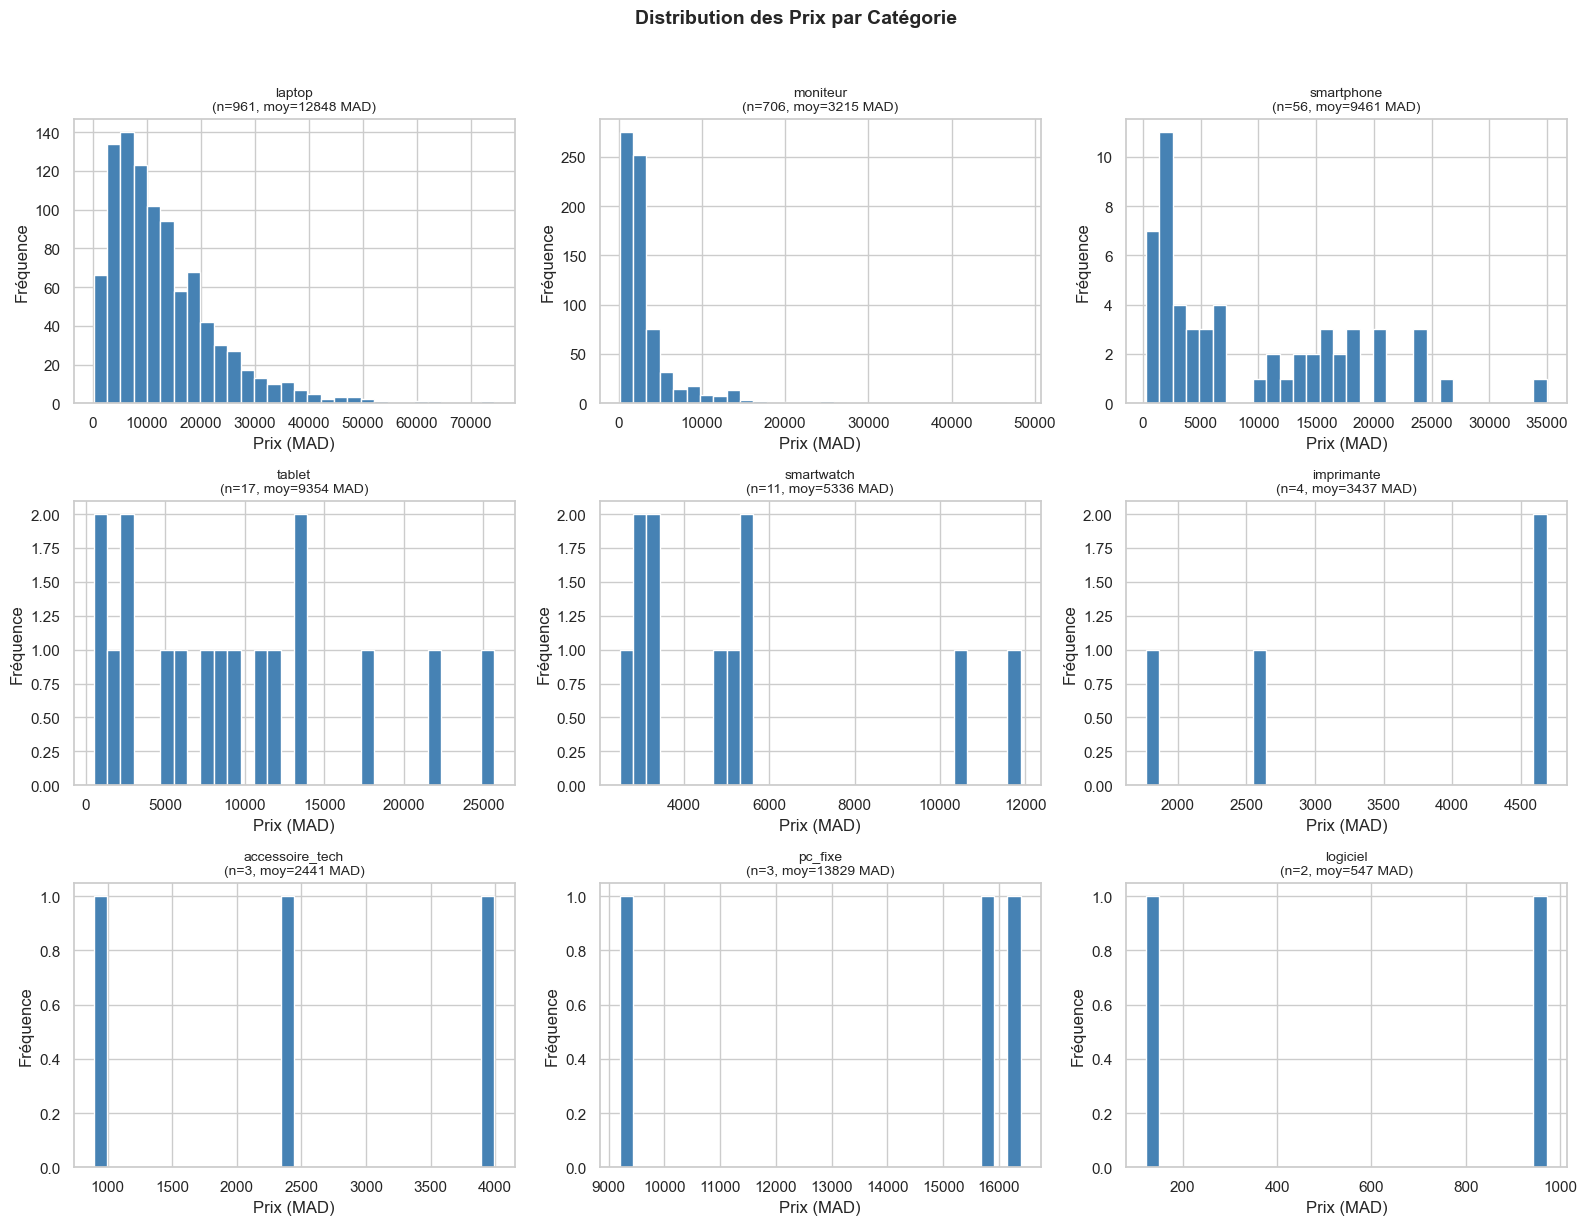

Graphique sauvegardé


In [8]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

categories = df['category'].value_counts().index

for i, cat in enumerate(categories):
    data = df[df['category'] == cat]['price']
    axes[i].hist(data, bins=30, color='steelblue', edgecolor='white')
    axes[i].set_title(f'{cat}\n(n={len(data)}, moy={data.mean():.0f} MAD)', fontsize=10)
    axes[i].set_xlabel('Prix (MAD)')
    axes[i].set_ylabel('Fréquence')

plt.suptitle('Distribution des Prix par Catégorie', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('charts/distribution_prix_categories.png',dpi=150,bbox_inches='tight')
plt.show()
print("Graphique sauvegardé")

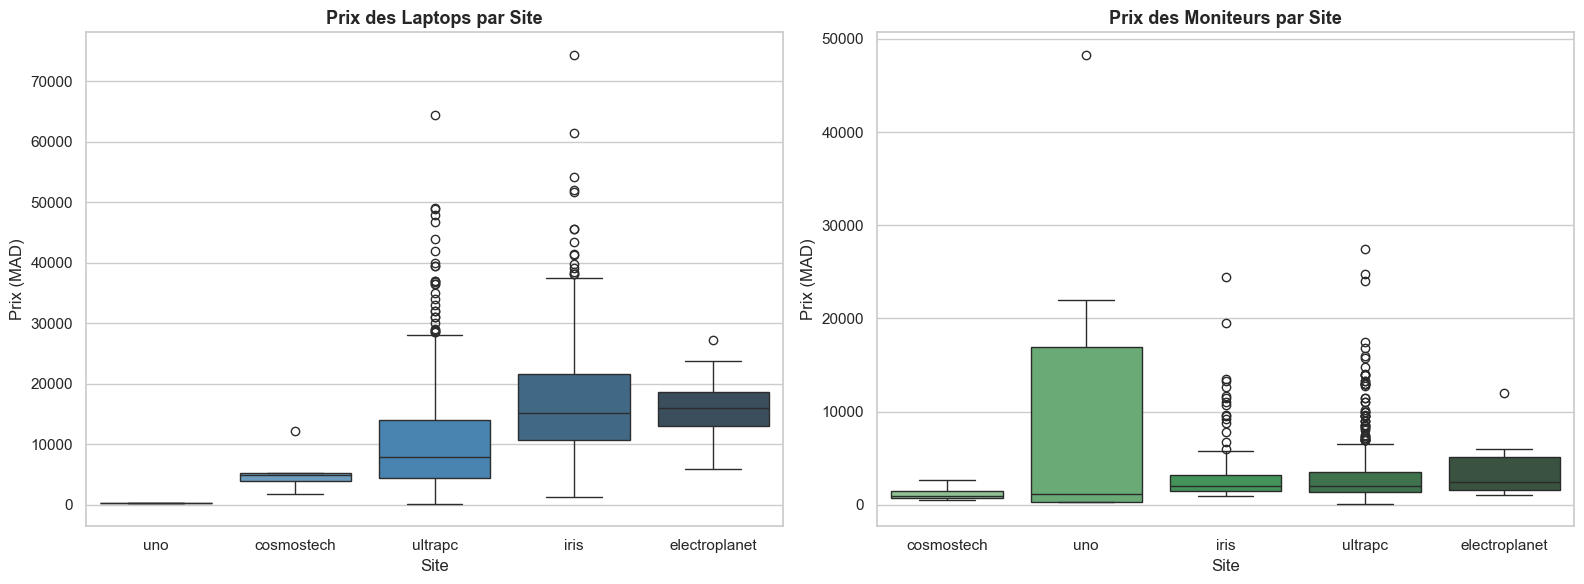

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Laptops par site
laptop_data = df[df['category'] == 'laptop']
sites_order = laptop_data.groupby('site')['price'].median().sort_values().index

sns.boxplot(data=laptop_data, x='site', y='price', order=sites_order,
            palette='Blues_d', ax=axes[0])
axes[0].set_title('Prix des Laptops par Site', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Site')
axes[0].set_ylabel('Prix (MAD)')

# Moniteurs par site
moniteur_data = df[df['category'] == 'moniteur']
sites_order2 = moniteur_data.groupby('site')['price'].median().sort_values().index

sns.boxplot(data=moniteur_data, x='site', y='price', order=sites_order2,
            palette='Greens_d', ax=axes[1])
axes[1].set_title('Prix des Moniteurs par Site', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Site')
axes[1].set_ylabel('Prix (MAD)')

plt.tight_layout()
plt.savefig('charts/boxplot_prix_sites.png', dpi=150, bbox_inches='tight')
plt.show()

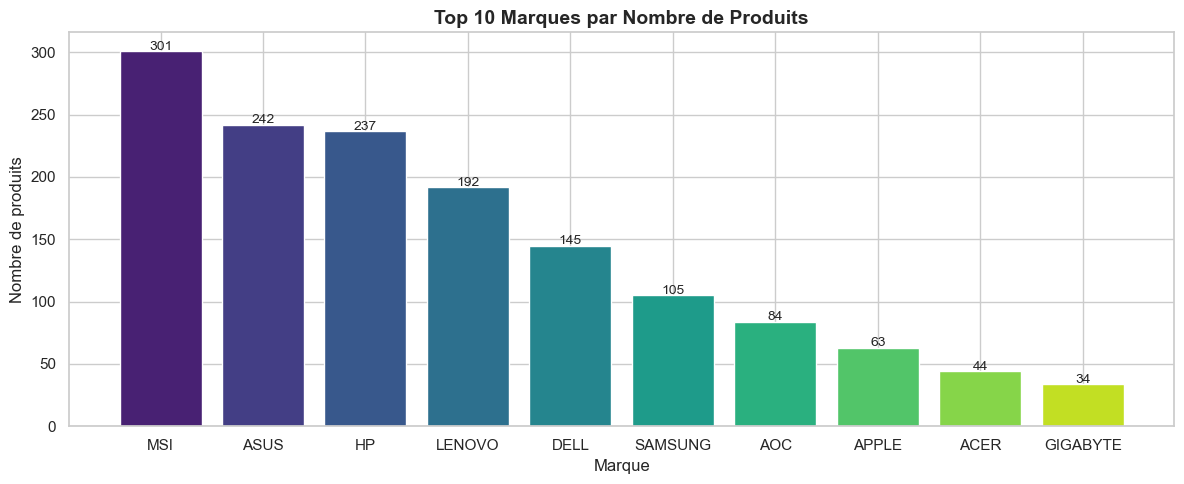

In [10]:
top_brands = df[df['brand'] != 'INCONNUE']['brand'].value_counts().head(10)

plt.figure(figsize=(12, 5))
bars = plt.bar(top_brands.index, top_brands.values, color=sns.color_palette('viridis', 10))
plt.title('Top 10 Marques par Nombre de Produits', fontsize=14, fontweight='bold')
plt.xlabel('Marque')
plt.ylabel('Nombre de produits')

for bar, val in zip(bars, top_brands.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             str(val), ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('charts/top_marques.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
outliers = df[df['is_outlier'] == True][['name', 'brand', 'category', 'site', 'price', 'price_zscore']]
outliers = outliers.sort_values('price', ascending=False)

print(f" {len(outliers)} produits outliers détectés\n")
print(outliers.to_string(index=False))

 27 produits outliers détectés

                                                                                      name    brand category    site  price  price_zscore
                         Ordinateur portable Gaming Asus ROG Zephyrus G16 (GU605CX-QR137W)     ASUS   laptop    iris  74399      7.000694
                                                     Razer Blade 16 i9-13950HX/32GB/2TB...    RAZER   laptop ultrapc  64499      5.932482
                                      Ordinateur portable Asus ProArt P16 (H7606WX-SE015W)     ASUS   laptop    iris  61399      5.597991
                      Ordinateur portable Gaming Lenovo Legion Pro 7 16IAX10H (83F50076FE)   LENOVO   laptop    iris  54199      4.821110
                         Ordinateur portable Gaming Asus ROG Strix SCAR 16 (G635LW-RW169W)     ASUS   laptop    iris  52099      4.594520
                         Ordinateur portable Gaming Asus ROG Zephyrus G16 (GU605CW-QR121W)     ASUS   laptop    iris  51699      4.551360
  

In [12]:
iris_laptops   = df[(df['category'] == 'laptop') & (df['site'] == 'iris')]['price']
ultra_laptops  = df[(df['category'] == 'laptop') & (df['site'] == 'ultrapc')]['price']

stat, p_value = stats.mannwhitneyu(iris_laptops, ultra_laptops, alternative='two-sided')

print("=" * 55)
print("  TEST MANN-WHITNEY — Laptops : iris.ma vs ultrapc")
print("=" * 55)
print(f"  Prix moyen iris.ma   : {iris_laptops.mean():.0f} MAD")
print(f"  Prix moyen ultrapc   : {ultra_laptops.mean():.0f} MAD")
print(f"  Statistique U        : {stat:.2f}")
print(f"  P-value              : {p_value:.6f}")
print("=" * 55)

if p_value < 0.05:
    print("  Différence SIGNIFICATIVE (p < 0.05)")
    print("  → iris.ma propose des prix significativement plus élevés")
else:
    print("  Pas de différence significative (p >= 0.05)")

  TEST MANN-WHITNEY — Laptops : iris.ma vs ultrapc
  Prix moyen iris.ma   : 17825 MAD
  Prix moyen ultrapc   : 10474 MAD
  Statistique U        : 143698.50
  P-value              : 0.000000
  Différence SIGNIFICATIVE (p < 0.05)
  → iris.ma propose des prix significativement plus élevés


In [13]:
categories_test = ['laptop', 'moniteur', 'smartphone', 'tablet', 'smartwatch']
groupes = [df[df['category'] == c]['price'].values for c in categories_test]

f_stat, p_value_anova = stats.f_oneway(*groupes)

print("=" * 50)
print("  TEST ANOVA — Prix selon les catégories")
print("=" * 50)
print(f"  F-statistique : {f_stat:.2f}")
print(f"  P-value       : {p_value_anova:.8f}")
print("=" * 50)

if p_value_anova < 0.05:
    print("  Différence SIGNIFICATIVE entre catégories")
    print("  → Les prix varient fortement selon la catégorie")
else:
    print("  Pas de différence significative")

print("\n  Prix médian par catégorie :")
for cat in categories_test:
    m = df[df['category'] == cat]['price'].median()
    print(f"    {cat:15s} : {m:.0f} MAD")

  TEST ANOVA — Prix selon les catégories
  F-statistique : 153.47
  P-value       : 0.00000000
  Différence SIGNIFICATIVE entre catégories
  → Les prix varient fortement selon la catégorie

  Prix médian par catégorie :
    laptop          : 10590 MAD
    moniteur        : 1999 MAD
    smartphone      : 5874 MAD
    tablet          : 8799 MAD
    smartwatch      : 4749 MAD


  RÉGRESSION — Prix ~ Price Rank
  Corrélation de Pearson : r = 0.852
  P-value corrélation    : 0.000000
  R² du modèle           : 0.725
  Coefficient price_rank : 73.97

  → Un rang plus élevé prédit un prix plus élevé (r=0.85)


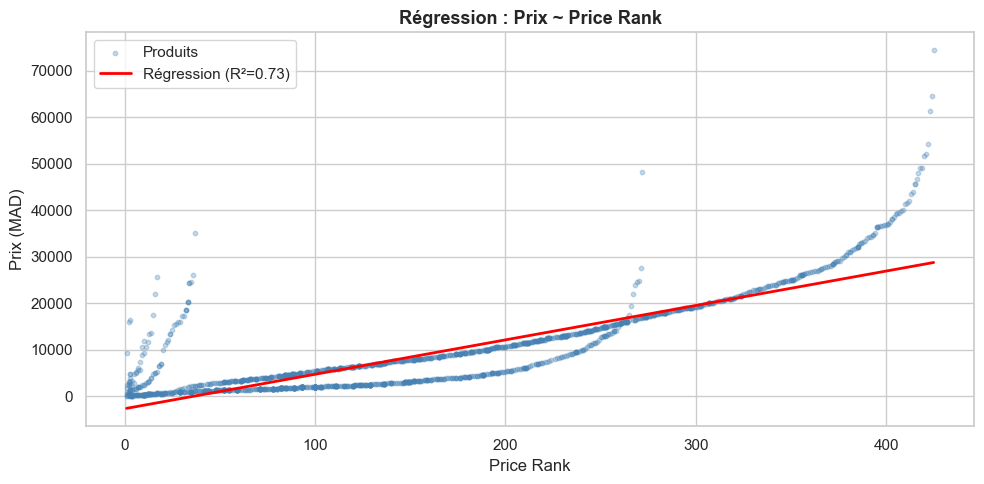

In [14]:
from scipy.stats import pearsonr
import statsmodels.api as sm

X = df['price_rank']
y = df['price']

# Corrélation 
corr, p_corr = pearsonr(X, y)

# Régression 
X_const = sm.add_constant(X)
model = sm.OLS(y, X_const).fit()

print("=" * 55)
print("  RÉGRESSION — Prix ~ Price Rank")
print("=" * 55)
print(f"  Corrélation de Pearson : r = {corr:.3f}")
print(f"  P-value corrélation    : {p_corr:.6f}")
print(f"  R² du modèle           : {model.rsquared:.3f}")
print(f"  Coefficient price_rank : {model.params['price_rank']:.2f}")
print("=" * 55)
print(f"\n  → Un rang plus élevé prédit un prix plus élevé (r={corr:.2f})")

# Graphique régression
plt.figure(figsize=(10, 5))
plt.scatter(X, y, alpha=0.3, color='steelblue', s=10, label='Produits')
plt.plot(sorted(X), [model.params['const'] + model.params['price_rank']*i for i in sorted(X)],
         color='red', linewidth=2, label=f'Régression (R²={model.rsquared:.2f})')
plt.xlabel('Price Rank')
plt.ylabel('Prix (MAD)')
plt.title('Régression : Prix ~ Price Rank', fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('charts/regression_prix_rank.png', dpi=150, bbox_inches='tight')
plt.show()

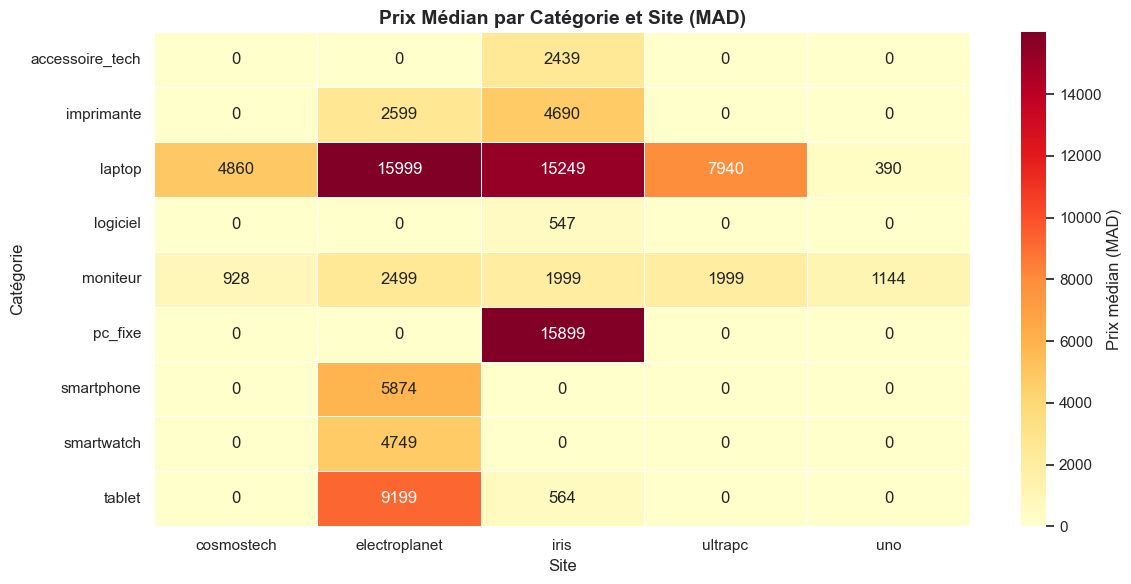

In [15]:
pivot = df.groupby(['category', 'site'])['price'].median().unstack(fill_value=0)

plt.figure(figsize=(12, 6))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': 'Prix médian (MAD)'})
plt.title('Prix Médian par Catégorie et Site (MAD)', fontsize=14, fontweight='bold')
plt.xlabel('Site')
plt.ylabel('Catégorie')
plt.tight_layout()
plt.savefig('charts/heatmap_prix.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
print("=" * 60)
print("         RAPPORT FINAL — PRICE INTELLIGENCE")
print("=" * 60)
print(f"\n📊 Données analysées : {len(df)} produits uniques")
print(f" Sites couverts    : {', '.join(df['site'].unique())}")
print(f" Catégories        : {df['category'].nunique()}")
print(f"  Marques           : {df['brand'].nunique()}")
print(f"\n Catégorie la + chère  : {df.groupby('category')['price'].median().idxmax()}")
print(f" Catégorie la - chère  : {df.groupby('category')['price'].median().idxmin()}")
print(f"\n Site le + cher (laptops) : iris.ma (moy: 17 825 MAD)")
print(f" Site le - cher (laptops) : cosmostech (moy: 5 601 MAD)")
print(f"\n Outliers détectés : {df['is_outlier'].sum()} produits (prix extrêmes)")
print(f"\n📈 TESTS STATISTIQUES :")
print(f"    Mann-Whitney iris vs ultrapc (laptops) : p < 0.0001 → Significatif")
print(f"    ANOVA entre catégories : F=153.47, p < 0.0001 → Significatif")
print(f"    Corrélation price_rank/prix : r=0.852 → Forte corrélation positive")
print(f"\n Graphiques sauvegardés dans le dossier courant")
print("=" * 60)

         RAPPORT FINAL — PRICE INTELLIGENCE

📊 Données analysées : 1763 produits uniques
 Sites couverts    : iris, cosmostech, ultrapc, uno, electroplanet
 Catégories        : 9
  Marques           : 30

 Catégorie la + chère  : pc_fixe
 Catégorie la - chère  : logiciel

 Site le + cher (laptops) : iris.ma (moy: 17 825 MAD)
 Site le - cher (laptops) : cosmostech (moy: 5 601 MAD)

 Outliers détectés : 27 produits (prix extrêmes)

📈 TESTS STATISTIQUES :
    Mann-Whitney iris vs ultrapc (laptops) : p < 0.0001 → Significatif
    ANOVA entre catégories : F=153.47, p < 0.0001 → Significatif
    Corrélation price_rank/prix : r=0.852 → Forte corrélation positive

 Graphiques sauvegardés dans le dossier courant
